***
#  📊 Exploration Data Analysis
***

**Index**

## Initial Set up

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Initial EDA

In [167]:
# Load the master file
# This file is expected to be a CSV file containing processed meat consumption data
# The path may vary based on your directory structure
# Ensure the file exists at the specified path before running this code
# If the file is not found, you may need to adjust the path accordingly


master_file = pd.read_csv('../Data/processed/meat_processed_merged_data.csv')


In [168]:
# Initial exploration of the master file

print(master_file.shape)  # Get the shape of the master file (rows, columns)
print(list(master_file.columns))  # List the columns in the master file
print(master_file.dtypes)  # Display the data types of each column
print(master_file.info()) # Get a concise summary of the DataFrame
print(master_file['Country'].nunique(), master_file['Year'].nunique())
print('-----------------------')
print( master_file.corr(numeric_only=True))  # Display the correlation matrix of the numerical columns
master_file.head(10)  # Display the first 10 rows of the master file

(1933, 9)
['Country', 'Year', 'Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat', 'Poultry Meat', 'GDP_per_capita', 'Urban_population', 'Production']
Country                object
Year                    int64
Bovine Meat           float64
Mutton & Goat Meat    float64
Pigmeat               float64
Poultry Meat          float64
GDP_per_capita        float64
Urban_population      float64
Production            float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1933 entries, 0 to 1932
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             1933 non-null   object 
 1   Year                1933 non-null   int64  
 2   Bovine Meat         1932 non-null   float64
 3   Mutton & Goat Meat  1933 non-null   float64
 4   Pigmeat             1887 non-null   float64
 5   Poultry Meat        1933 non-null   float64
 6   GDP_per_capita      1927 non-null   float64
 7   Urban_population  

,Country,Year,Bovine Meat,Mutton & Goat Meat,Pigmeat,Poultry Meat,GDP_per_capita,Urban_population,Production
0,Afghanistan,2010,4.74,5.04,NaN,2.29,560.621505,23.737,328160.00
1,Afghanistan,2011,4.80,4.66,NaN,1.92,606.694676,23.948,335664.00
2,Afghanistan,2012,4.40,5.03,NaN,2.05,651.417134,24.160,330600.00
3,Afghanistan,2013,4.18,5.20,NaN,2.11,637.087099,24.373,322110.00
4,Afghanistan,2014,4.99,5.06,0.03,2.11,625.054942,24.587,311019.70
5,Afghanistan,2015,3.81,4.77,0.02,1.96,565.569730,24.803,302781.28
6,Afghanistan,2016,3.28,4.80,0.01,2.00,522.082216,25.020,295536.47
7,Afghanistan,2017,2.92,4.45,0.02,1.79,525.469771,25.250,313220.84
8,Afghanistan,2018,2.67,4.32,0.03,1.46,491.337221,25.495,293127.78
9,Afghanistan,2019,2.76,3.45,0.04,1.81,496.602504,25.754,285593.30


## Nan analisis

Checking the type of meat consuption in each country and if there is missing data in the master file

In [169]:
print(master_file.isnull().sum())

Country                0
Year                   0
Bovine Meat            1
Mutton & Goat Meat     0
Pigmeat               46
Poultry Meat           0
GDP_per_capita         6
Urban_population       0
Production             0
dtype: int64


Some countries do not consume pig meat and only one country does not consume Bovine Meat (cow). 

In the following we analise if this is due to real 'missing' data or real zero consumption

In [170]:
# According to the general Nan results, check which countries have NaN values in the 'Pigmeat' and 'Bovine Meat' columns
pigmeat_nan_df = master_file[master_file["Pigmeat"].isna()]
cow_nan_df = master_file[master_file["Bovine Meat"].isna()]
# Print it as a list 
print('Countries twith Nan in pig meat:', list(pigmeat_nan_df['Country'].unique()) ) # List countries with NaN in Pigmeat column
print('Countries with Nan in cow meat:', list(cow_nan_df['Country'].unique()) )# List countries with NaN in Bovine Meat column


Countries twith Nan in pig meat: ['Afghanistan', 'Kuwait', 'Mauritania', 'Pakistan', 'Saudi Arabia', 'Tunisia', 'United Arab Emirates']
Countries with Nan in cow meat: ['Kiribati']


Countries with null meat consuption of pig (muslim countries), cow (not vialbe its production) $\to$ We safely set the Nans to zero values

In [171]:
# Create the list of countries with NaN values in pig meat and cow meat in our master dataset 
muslum_countries = list(pigmeat_nan_df['Country'].unique())
# These countries are Muslim countries, and so NaN indicates null consumption or restringered/negligible. We can safely set this to 0
master_file.loc[master_file['Country'].isin(muslum_countries) & (master_file['Pigmeat'].isnull()), 'Pigmeat'] = 0           
master_file.loc[master_file['Country'].isin(list(cow_nan_df['Country'].unique())) & (master_file['Bovine Meat'].isnull()), 'Bovine Meat'] = 0
print(master_file.isnull().sum())

Country               0
Year                  0
Bovine Meat           0
Mutton & Goat Meat    0
Pigmeat               0
Poultry Meat          0
GDP_per_capita        6
Urban_population      0
Production            0
dtype: int64


In [173]:
gdp_per_capita =master_file[master_file['GDP_per_capita'].isna()]
print('Countries with NaN in GDP per capita:', list(gdp_per_capita['Country'].unique()) ) # List countries with NaN in GDP per capita column
gdp_per_capita

Countries with NaN in GDP per capita: ['Cuba', 'South Sudan']


,Country,Year,Bovine Meat,Mutton & Goat Meat,Pigmeat,Poultry Meat,GDP_per_capita,Urban_population,Production
440,Cuba,2021,7.90,2.18,17.25,32.45,NaN,77.292,257217.00
441,Cuba,2022,8.09,1.68,18.81,29.80,NaN,77.401,315534.97
1663,South Sudan,2019,13.16,4.80,0.01,8.41,NaN,19.899,295223.00
1664,South Sudan,2020,12.21,3.64,0.01,3.47,NaN,20.199,223535.20
1665,South Sudan,2021,11.87,3.66,0.00,4.71,NaN,20.514,237110.27
1666,South Sudan,2022,12.07,3.89,0.00,4.77,NaN,20.846,248472.56


We can safely delete these data since there is no big impact on the study

In [174]:
# Delete Nan rows 
master_file =master_file[~master_file['GDP_per_capita'].isna()]
print(master_file.isnull().sum()  )

Country               0
Year                  0
Bovine Meat           0
Mutton & Goat Meat    0
Pigmeat               0
Poultry Meat          0
GDP_per_capita        0
Urban_population      0
Production            0
dtype: int64


## Distribution of meat consumption 

Questions to Explore

1. What is the most consumed type of meat per country, and which one predominates globally?
2. Which countries consume the most of each meat type (bovine, pig, poultry, mutton)?
3. How has the global per capita meat consumption evolved from 2010 to 2022?
4. Which countries are in the top 5 for overall per capita meat consumption?


### 1. What is the most consumed type of meat per country, and which one predominates globally?

In [117]:


# Compute total meat consumption per country
meat_columns = ['Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat', 'Poultry Meat']
master_file['Total_meat'] = master_file[meat_columns].sum(axis=1)

In [118]:
# Split into two dataset: one for 1010-2022 rante and the secong done for 2022 lates year

# Dataset average by country(2010–2022)


df_avg = master_file.groupby('Country')['Total_meat'].mean().reset_index().rename(columns={'Total_meat': 'avg_meat'})


# Dataset for year 2022
df_2022 = master_file[master_file['Year'] == 2022][['Country', 'Total_meat']].rename(columns={'Total_meat': 'meat_2022'})


In [119]:
# Creating different groups based on average meat consumption
df_avg['consumption_group_avg'] = pd.qcut(df_avg['avg_meat'], 5, labels=['Low', 'Medium-low', 'Medium-high', 'High', 'Extremely high'])

# Creating different groups based on meat consumption in 2022
df_2022['consumption_group_2022'] = pd.qcut(df_2022['meat_2022'], 5, labels=['Low', 'Medium-low', 'Medium-high', 'High', 'Extremely high'])


In [120]:
# Unimos el grupo por promedio al dataframe general
master_file= master_file.merge(df_avg[['Country', 'consumption_group_avg']], on='Country', how='left')

# Unimos también el grupo por 2022
master_file = master_file.merge(df_2022[['Country', 'consumption_group_2022']], on='Country', how='left')

In [121]:
master_file

,Country,Year,Bovine Meat,Mutton & Goat Meat,Pigmeat,Poultry Meat,GDP_per_capita,Urban_population,Production,Total_meat,consumption_group_avg,consumption_group_2022
0,Afghanistan,2010,4.74,5.04,0.00,2.29,560.621505,23.737,328160.0,12.07,Low,Low
1,Afghanistan,2011,4.80,4.66,0.00,1.92,606.694676,23.948,335664.0,11.38,Low,Low
2,Afghanistan,2012,4.40,5.03,0.00,2.05,651.417134,24.160,330600.0,11.48,Low,Low
3,Afghanistan,2013,4.18,5.20,0.00,2.11,637.087099,24.373,322110.0,11.49,Low,Low
4,Afghanistan,2014,4.99,5.06,0.03,2.11,625.054942,24.587,311019.7,12.19,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
1922,Zimbabwe,2018,40.99,1.82,0.52,4.38,2271.852504,32.209,771502.0,47.71,Medium-high,Medium-high
1923,Zimbabwe,2019,40.98,1.77,0.69,4.47,1683.913136,32.210,823826.1,47.91,Medium-high,Medium-high
1924,Zimbabwe,2020,40.12,1.76,0.64,7.21,1730.453910,32.242,821114.4,49.73,Medium-high,Medium-high
1925,Zimbabwe,2021,43.77,1.95,0.73,7.33,1724.387271,32.303,895893.5,53.78,Medium-high,Medium-high


In [122]:
df_avg['consumption_group_avg'].value_counts()

consumption_group_avg
Low               31
Medium-low        31
High              31
Extremely high    31
Medium-high       30
Name: count, dtype: int64

In [133]:
meat_means_by_group_ave = master_file.groupby('consumption_group_avg')[['Bovine Meat', 'Pigmeat', 'Poultry Meat', 'Mutton & Goat Meat']].mean()
meat_means_by_group_ave


,Bovine Meat,Pigmeat,Poultry Meat,Mutton & Goat Meat
consumption_group_avg,,,,
Low,3.428223,1.962944,3.533350,1.703858
Medium-low,8.058778,3.929651,11.021496,2.872618
Medium-high,11.178753,7.869247,24.696390,3.644545
High,13.456675,23.913553,28.052665,2.576269
Extremely high,20.762578,27.172181,36.136261,5.824844


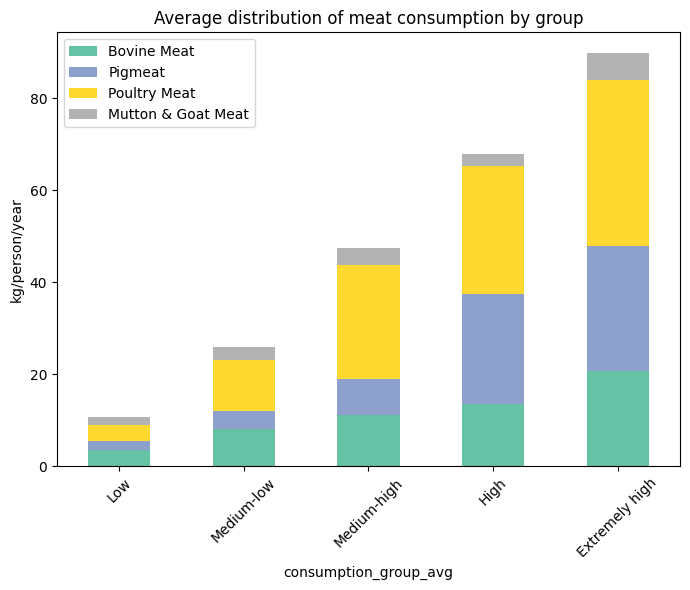

In [139]:
meat_means_by_group_ave.plot(kind='bar', stacked=True, colormap='Set2', figsize=(7,6))
plt.title('Average distribution of meat consumption by group')
plt.ylabel('kg/person/year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


CHiken meat `Poultry Meat' predominates in all groups.

In [140]:
meat_means_by_group_2022 = master_file.groupby('consumption_group_2022')[['Bovine Meat', 'Pigmeat', 'Poultry Meat', 'Mutton & Goat Meat']].mean()
meat_means_by_group_2022

,Bovine Meat,Pigmeat,Poultry Meat,Mutton & Goat Meat
consumption_group_2022,,,,
Low,3.815198,1.886728,3.025673,1.907916
Medium-low,6.774350,4.160822,11.439523,2.660186
Medium-high,12.375538,7.522564,22.271667,3.523154
High,13.643641,24.436658,27.678832,2.313207
Extremely high,20.203399,22.650765,38.425042,6.487762


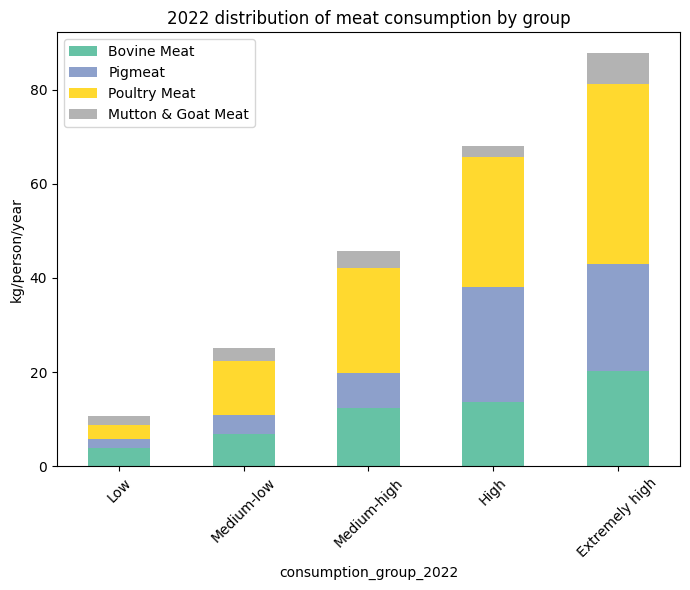

In [138]:
meat_means_by_group_2022.plot(kind='bar', stacked=True, colormap='Set2', figsize=(7,6))
plt.title('2022 distribution of meat consumption by group')
plt.ylabel('kg/person/year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CHiken meat `Poultry Meat' predominates in all groups, and average across time is stable, not big changes found from latrs to average data

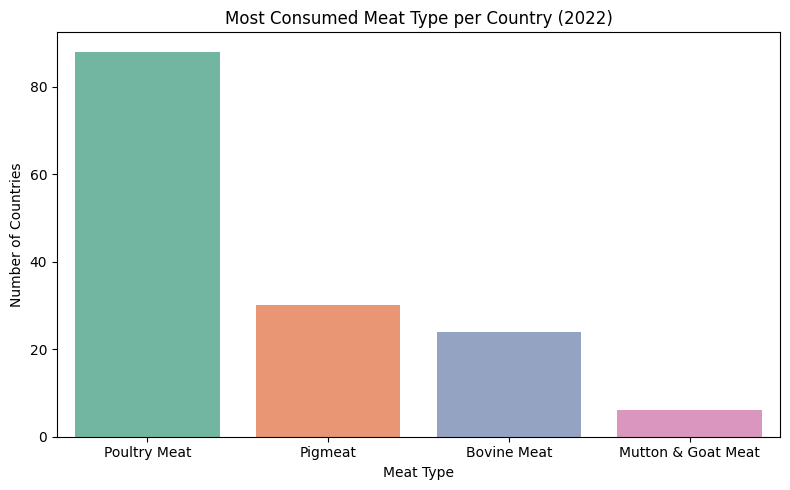

In [141]:
# 1. Select data for the year 2022
df_2022 = master_file[master_file['Year'] == 2022].copy()

# 2. Select relevant meat consumption columns
meat_columns = ['Bovine Meat', 'Mutton & Goat Meat', 'Pigmeat', 'Poultry Meat']

# 3. Identify the most consumed meat type per country
df_2022['most_consumed_meat'] = df_2022[meat_columns].idxmax(axis=1)

# 4. Visualize the distribution of dominant meat types


plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_2022,
    x='most_consumed_meat',
    order=df_2022['most_consumed_meat'].value_counts().index,
    palette='Set2'
)
plt.title("Most Consumed Meat Type per Country (2022)")
plt.xlabel("Meat Type")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.show()


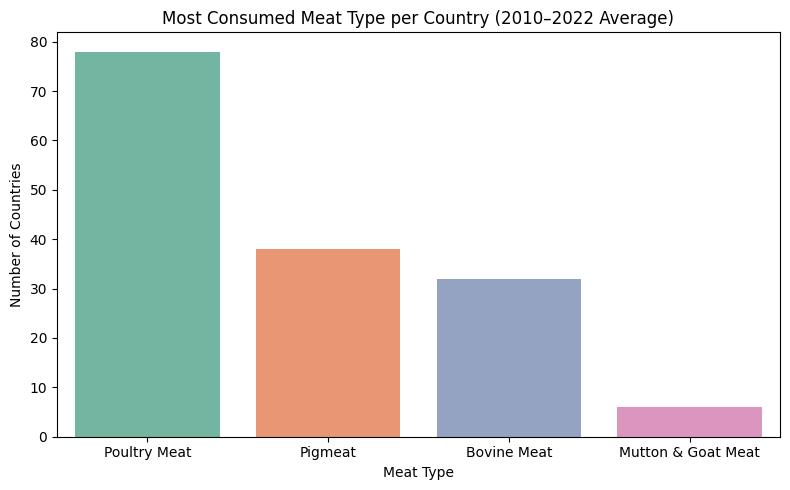

In [142]:
# Group by country and compute average consumption per meat type
avg_meat_by_country = master_file.groupby('Country')[meat_columns].mean().reset_index()

# Identify the meat type with highest average consumption per country
avg_meat_by_country['most_consumed_meat_avg'] = avg_meat_by_country[meat_columns].idxmax(axis=1)

# Plot the distribution of dominant meat types (average)
plt.figure(figsize=(8, 5))
sns.countplot(
    data=avg_meat_by_country,
    x='most_consumed_meat_avg',
    order=avg_meat_by_country['most_consumed_meat_avg'].value_counts().index,
    palette='Set2'
)
plt.title("Most Consumed Meat Type per Country (2010–2022 Average)")
plt.xlabel("Meat Type")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.show()


In [153]:
# Creat the total meat  
master_file['Total_meat'] = (
    master_file['Bovine Meat'] +
    master_file['Pigmeat'] +
    master_file['Poultry Meat'] +
    master_file['Mutton & Goat Meat']
)


In [147]:
df_2022 = master_file[master_file['Year'] == 2022][['Country', 'Total_meat']].rename(columns={'Total_meat': 'meat_2022'})


In [150]:
top_5 = df_2022.sort_values(by='meat_2022', ascending=False).head(5)
bottom_5 = df_2022.sort_values(by='meat_2022', ascending=True).head(5)

print(" Top 5 meat-consuming countries in 2022 (kg/person/year):")
print(top_5[['Country', 'meat_2022']])

print("\n Bottom 5 meat-consuming countries in 2022 (kg/person/year):")
print(bottom_5[['Country', 'meat_2022']])


 Top 5 meat-consuming countries in 2022 (kg/person/year):
        Country  meat_2022
1779      Tonga     147.51
878      Israel     113.18
77    Argentina     112.08
103   Australia     111.40
1197   Mongolia     108.47

 Bottom 5 meat-consuming countries in 2022 (kg/person/year):
         Country  meat_2022
290      Burundi       3.63
146   Bangladesh       4.25
1517      Rwanda       4.97
1080  Madagascar       5.21
1331       Niger       5.25


### 2. Which countries consume the most of each meat type (bovine, pig, poultry, mutton)?